In [2]:
# Training script for ML fraud detection model
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
df = pd.read_csv("C:/Users/LENOVO L480/Downloads/CreditCardFraudDetection/CreditCardFraudDetection/dataset/creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df.shape)

(284807, 31)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

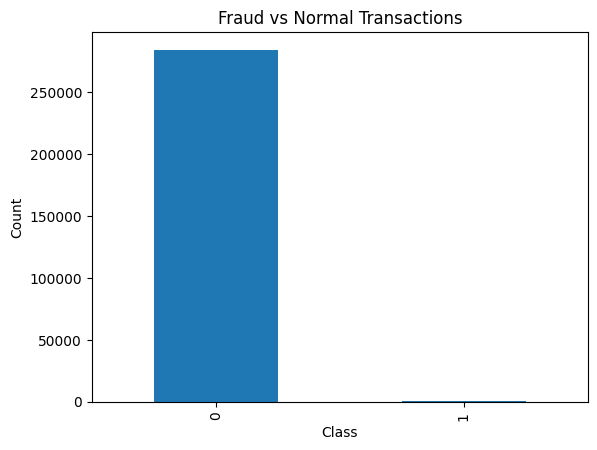

In [7]:
df['Class'].value_counts().plot(kind='bar')

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [8]:
print(df['Amount'].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [9]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print(fraud['Amount'].describe())
print(normal['Amount'].describe())

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [10]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\LENOVO L480\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


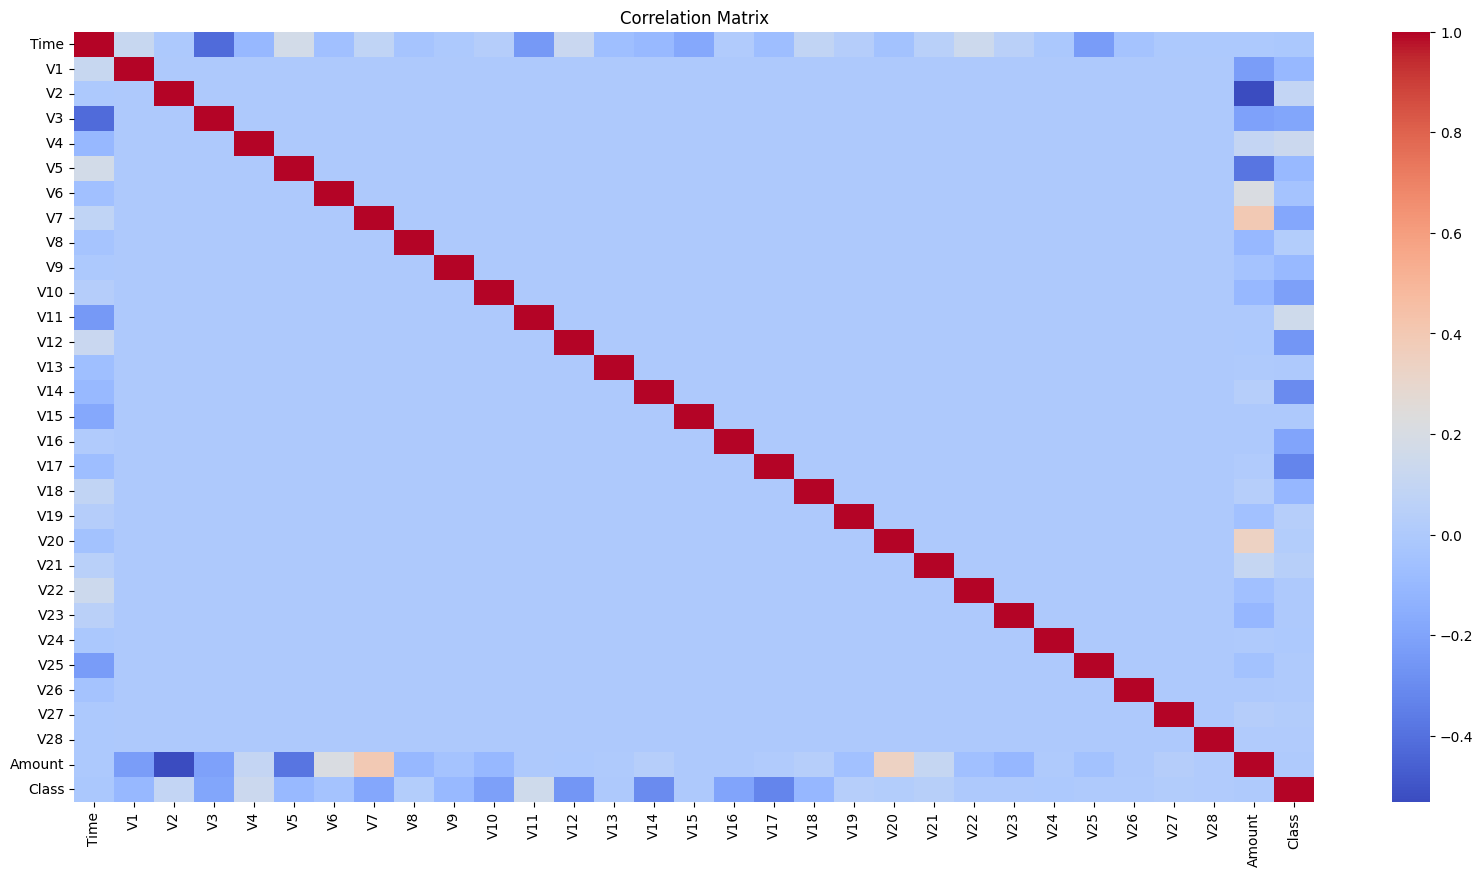

In [11]:
import seaborn as sns
plt.figure(figsize=(20,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df[['Amount', 'scaled_amount']].head()
df = df.drop(['Amount'], axis=1)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


In [13]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\LENOVO L480\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
 # ==========================================
# Credit Card Fraud Detection
# Data Preprocessing Pipeline
# ==========================================

# -------------------------------
# Import Required Libraries
# -------------------------------

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# -------------------------------
# Create Features (X) and Target (y)
# -------------------------------

X = df.drop('Class', axis=1)

y = df['Class']

# -------------------------------
# Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------
# Display Dataset Shapes
# -------------------------------

print("Training Feature Shape:")
print(X_train.shape)

print("\nTesting Feature Shape:")
print(X_test.shape)

print("\nTraining Target Shape:")
print(y_train.shape)

print("\nTesting Target Shape:")
print(y_test.shape)

# -------------------------------
# Before SMOTE
# -------------------------------

print("\nClass Distribution Before SMOTE:")
print(y_train.value_counts())

# -------------------------------
# Apply Partial SMOTE
# -------------------------------

smote = SMOTE(
    sampling_strategy={1: 5000},
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

# -------------------------------
# After SMOTE
# -------------------------------

print("\nClass Distribution After Partial SMOTE:")
print(y_train_resampled.value_counts())

# -------------------------------
# Final ML-ready Data Shapes
# -------------------------------

print("\nFinal Resampled Training Feature Shape:")
print(X_train_resampled.shape)

print("\nFinal Resampled Training Target Shape:")
print(y_train_resampled.shape)

print("\nData Preprocessing Completed Successfully!")

Training Feature Shape:
(227845, 30)

Testing Feature Shape:
(56962, 30)

Training Target Shape:
(227845,)

Testing Target Shape:
(56962,)

Class Distribution Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Class Distribution After Partial SMOTE:
Class
0    227451
1      5000
Name: count, dtype: int64

Final Resampled Training Feature Shape:
(232451, 30)

Final Resampled Training Target Shape:
(232451,)

Data Preprocessing Completed Successfully!


In [15]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\LENOVO L480\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [22]:
# ==========================================
# Credit Card Fraud Detection
# Model Training & Evaluation
# ==========================================

# -------------------------------
# Import ML Models
# -------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# -------------------------------
# Import Evaluation Metrics
# -------------------------------

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ==========================================
# 1️⃣ Logistic Regression
# ==========================================

print("===================================")
print("LOGISTIC REGRESSION")
print("===================================")

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train_resampled, y_train_resampled)

# Predictions
lr_predictions = lr_model.predict(X_test)

# Evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_predictions))

print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

# ROC-AUC Score
lr_roc_auc = roc_auc_score(y_test, lr_predictions)

print("\nROC-AUC Score:")
print(lr_roc_auc)

# ==========================================
# 2️⃣ Decision Tree
# ==========================================

print("\n\n===================================")
print("DECISION TREE")
print("===================================")

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train_resampled, y_train_resampled)

# Predictions
dt_predictions = dt_model.predict(X_test)

# Evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

# ROC-AUC Score
dt_roc_auc = roc_auc_score(y_test, dt_predictions)

print("\nROC-AUC Score:")
print(dt_roc_auc)

# ==========================================
# 3️⃣ Random Forest
# ==========================================

print("\n\n===================================")
print("RANDOM FOREST")
print("===================================")

# Create model
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_resampled, y_train_resampled)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

# ROC-AUC Score
rf_roc_auc = roc_auc_score(y_test, rf_predictions)

print("\nROC-AUC Score:")
print(rf_roc_auc)

# ==========================================
# Final Comparison
# ==========================================

print("\n\n===================================")
print("MODEL COMPARISON")
print("===================================")

print(f"Logistic Regression ROC-AUC : {lr_roc_auc:.4f}")
print(f"Decision Tree ROC-AUC       : {dt_roc_auc:.4f}")
print(f"Random Forest ROC-AUC       : {rf_roc_auc:.4f}")

LOGISTIC REGRESSION


C:\Users\LENOVO L480\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Confusion Matrix:
[[56820    44]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.65      0.84      0.73        98

    accuracy                           1.00     56962
   macro avg       0.83      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score:
0.9179804589252696


DECISION TREE

Confusion Matrix:
[[56791    73]
 [   20    78]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.52      0.80      0.63        98

    accuracy                           1.00     56962
   macro avg       0.76      0.90      0.81     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score:
0.8973173012874255


RANDOM FOREST


C:\Users\LENOVO L480\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\LENOVO L480\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\LENOVO L480\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklear


Confusion Matrix:
[[56846    18]
 [   13    85]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.87      0.85        98

    accuracy                           1.00     56962
   macro avg       0.91      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score:
0.9335151970185936


MODEL COMPARISON
Logistic Regression ROC-AUC : 0.9180
Decision Tree ROC-AUC       : 0.8973
Random Forest ROC-AUC       : 0.9335


In [20]:
pip install xgboost

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\LENOVO L480\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 578.7 kB/s eta 0:02:55
   ---------------------------------------- 0.8/101.7 MB 644.9 kB/s eta 0:02:37
   ---------------------------------------- 0.8/101.7 MB 644.9 kB/s eta 0:02:37
   ---------------------------------------- 1.0/101.7 MB 629.1 kB/s eta 0:02:40
   ---------------------------------------- 1.0/101.7 MB 629.1 kB/s eta 0:02:40
    --------------------------------------- 1.3/101.7 MB 670.9 kB/s eta 0:02:30
    --------------------------------------- 1.3/101.7 MB 670.9 kB/s eta 0:02:30
    ----------

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\threading.py:986: ResourceWarning: unclosed file <_io.BufferedWriter name=4>
  del self._target, self._args, self._kwargs
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\threading.py:986: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  del self._target, self._args, self._kwargs
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\threading.py:986: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  del self._target, self._args, self._kwargs


In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train_resampled, y_train_resampled)

xgb_predictions = xgb_model.predict(X_test)

print(confusion_matrix(y_test, xgb_predictions))

print(classification_report(y_test, xgb_predictions))

xgb_roc_auc = roc_auc_score(y_test, xgb_predictions)

print("ROC-AUC Score:", xgb_roc_auc)

[[56849    15]
 [   15    83]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.85      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9233374941141341


In [26]:
import joblib

joblib.dump(
    rf_model,
    "../models/fraud_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!
